In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My Drive/single_cell_isoform_smoothing/

/content/drive/My Drive/single_cell_isoform_smoothing


In [ ]:
!pip install scanpy
!pip install diptest
!pip install --upgrade networkx
!pip install SCORED

import numpy as np
import pandas as pd
import sklearn
import scipy
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.notebook import tqdm
import networkx as nx
import torch
from scipy.sparse import csr_matrix


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.4/255.4 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.7/222.7 kB 17.7 MB/s eta 0:00:00


In [ ]:
if torch.cuda.is_available():
  dev = "cuda:0"
else:
  dev = "cpu"
device = torch.device(dev)

if torch.cuda.is_available():
   print ("Cuda is available")
   device_id = torch.cuda.current_device()
   gpu_properties = torch.cuda.get_device_properties(device_id)
   print("Found %d GPUs available. Using GPU %d (%s) of compute capability %d.%d with "
          "%.1fGb total memory.\n" %
          (torch.cuda.device_count(),
          device_id,
          gpu_properties.name,
          gpu_properties.major,
          gpu_properties.minor,
          gpu_properties.total_memory / 1e9))
else:
   print ("Cuda is not available")

Cuda is available
Found 1 GPUs available. Using GPU 0 (NVIDIA A100-SXM4-40GB) of compute capability 8.0 with 42.5Gb total memory.



In [ ]:
def simrank_similarity_optimized(adj_matrix, decay_factor=0.8, max_iter=1000, eps=1e-4, device='cpu'):
    """
    Optimized SimRank similarity computation using matrix operations to avoid for loops.

    Parameters:
    adj_matrix (torch.Tensor): Adjacency matrix (n x n) where n is the number of nodes.
    decay_factor (float): Decay factor (C) in the SimRank equation, usually between 0 and 1.
    max_iter (int): Maximum number of iterations to run the algorithm.
    eps (float): Convergence threshold for stopping criterion.
    device (str): Device to run the computation ('cpu' or 'cuda').

    Returns:
    torch.Tensor: SimRank similarity matrix (n x n).
    """
    n = adj_matrix.shape[0]  # Number of nodes
    sim_matrix = torch.eye(n, device=device)  # Initialize similarity matrix as identity (self-similarity = 1)

    # Normalize the adjacency matrix by the out-degree (number of neighbors)
    out_degrees = adj_matrix.sum(dim=1, keepdim=True)
    norm_adj_matrix = torch.where(out_degrees > 0, adj_matrix / out_degrees, adj_matrix).to(device)

    # Iterate to update similarity scores
    for _ in range(max_iter):
        new_sim_matrix = sim_matrix.clone()  # Copy the similarity matrix for updating

        # Compute pairwise similarities using matrix operations
        sim_scores = torch.matmul(norm_adj_matrix, torch.matmul(sim_matrix, norm_adj_matrix.T))
        new_sim_matrix = decay_factor * sim_scores

        # Ensure self-similarity remains 1 (diagonal elements)
        new_sim_matrix.fill_diagonal_(1)

        # Check for convergence
        if torch.norm(new_sim_matrix - sim_matrix) < eps:
            break

        sim_matrix = new_sim_matrix

    return sim_matrix


def gaussian_kernel_weights_with_simrank(distances: csr_matrix, sim_matrix: np.ndarray, k: int, device='cpu') -> torch.Tensor:
    """
    Calculate Gaussian kernel-based weights for a kNN graph based on distances and SimRank similarity matrix.

    Parameters
    ----------
    distances: csr_matrix
        The input sparse matrix of distances between cells. Non-nearest neighbors are set to 0.

    sim_matrix: np.ndarray
        The SimRank similarity matrix (dense, NumPy array).

    k: int
        The number of nearest neighbors to consider for intersection.

    device: str
        Device for torch tensors ('cpu' or 'cuda').

    Returns
    -------
    weights: torch.Tensor
        A symmetric weight matrix with Gaussian kernel weights.
    """
    # Convert the sparse distance matrix to dense and move to the specified device
    distances_dense = distances.toarray()
    distances_tensor = torch.tensor(distances_dense, dtype=torch.float32).to(device)

    # Convert SimRank matrix to torch tensor and move to device
    simrank_tensor = torch.tensor(sim_matrix, dtype=torch.float32).to(device)

    # Initialize an empty matrix for weights
    n_cells = distances_tensor.shape[0]
    weights = torch.zeros_like(distances_tensor, device=device)

    # Calculate sigma (median of non-zero distances) for each cell
    sigmas_sq = torch.zeros(n_cells, device=device)

    for i in range(n_cells):
        non_zero_distances = distances_tensor[i][distances_tensor[i] > 0]

        if len(non_zero_distances) > 0:
            sigmas_sq[i] = torch.median(non_zero_distances ** 2)

    # Compute sigma by taking the square root of sigmas_sq
    sigmas = torch.sqrt(sigmas_sq)

    # Compute the Gaussian kernel weights based on the intersection of kNN neighbors and top-k SimRank
    for i in range(n_cells):
        # Step 1: Find original nearest neighbors from the kNN graph
        knn_neighbors = torch.where(distances_tensor[i] > 0)[0].cpu().numpy()

        # Step 2: Find top k most similar cells from SimRank
        top_k_simrank_neighbors = np.argsort(-sim_matrix[i])[:k]  # Get indices of top k most similar

        # Step 3: Compute intersection of the two sets
        common_neighbors = np.intersect1d(knn_neighbors, top_k_simrank_neighbors)

        # Step 4: Compute weights for common neighbors using the Gaussian kernel
        for j in common_neighbors:
            Dsq_ij = distances_tensor[i, j] ** 2
            sigma_i_sq = sigmas_sq[i]
            sigma_j_sq = sigmas_sq[j]
            Num = 2 * sigmas[i] * sigmas[j]
            Den = sigma_i_sq + sigma_j_sq
            weights[i, j] = torch.sqrt(Num / Den) * torch.exp(-Dsq_ij / Den)

    # Symmetrize the weight matrix
    weights = weights + weights.T

    return weights

def rwr_impute(sim_matrix_df_norm, adata_normalized, alpha=0.1, max_iter=100, tol=1e-5, device='cpu'):
    """
    Perform Random Walk with Restart (RWR) on a similarity matrix and apply the result to normalize a gene expression matrix.

    Parameters:
    - sim_matrix_df_norm: pd.DataFrame, normalized similarity matrix.
    - adata_normalized: AnnData object or equivalent containing the normalized gene expression matrix.
    - alpha: float, restart probability (default: 0.1).
    - max_iter: int, maximum number of iterations (default: 100).
    - tol: float, tolerance for convergence (default: 1e-4).
    - device: str, either 'cuda' or 'cpu' depending on whether you want to leverage GPU acceleration (default: 'cpu').

    Returns:
    - new_matrix: np.ndarray, the resulting matrix after RWR and matrix multiplication.
    """

    # Convert the similarity matrix to a numpy array and then to a PyTorch tensor on the GPU
    sim_matrix_np = sim_matrix_df_norm.to_numpy()
    T = torch.tensor(sim_matrix_np, dtype=torch.float32, device=device)

    # Initialize the probability matrix with the identity matrix
    n = T.shape[0]
    P0 = torch.eye(n, dtype=torch.float32, device=device)
    P = P0.clone()

    # Perform the Random Walk with Restart
    for i in range(max_iter):
        P_new = (1 - alpha) * torch.matmul(P, T) + alpha * P0

        # Check for convergence
        if torch.norm(P_new - P) < tol:
            print(f"Random walk with restart converged in {i} iterations.")
            break

        P = P_new

    # Move the final P matrix back to CPU and convert it to a numpy array
    P_final = P.cpu().numpy()

    # Extract the normalized gene expression matrix from the AnnData object
    normalized_matrix = adata_normalized.X.toarray() if hasattr(adata_normalized.X, "toarray") else np.array(adata_normalized.X)

    # Convert the dense matrices to PyTorch tensors and move them to the GPU
    normalized_matrix_tensor = torch.tensor(normalized_matrix, dtype=torch.float32).to(device)
    P_matrix_tensor = torch.tensor(P_final, dtype=torch.float32).to(device)

    # Perform matrix multiplication (P.T @ normalized_matrix)
    new_matrix_tensor = torch.mm(P_matrix_tensor.T, normalized_matrix_tensor)

    # Move the result back to CPU and convert it to a numpy array
    new_matrix = new_matrix_tensor.cpu().numpy()

    return new_matrix, P_final


In [ ]:

### Load in ADT confident cell type label
url = 'https://raw.githubusercontent.com/tarot0410/SECANT/main/real_data/10X10k_PBMC/'
ADT_df = pd.read_csv(url + 'label_10X10k.csv')
# Create the mapping dictionary
mapping = {
    1: 'B cells',
    2: 'CD14+Mono',
    3: 'CD4+T cells',
    4: 'CD8+T cells',
    5: 'NK cells',
    6: 'Uncertain'
}

# Apply the mapping to the 'x' column
ADT_df['x'] = ADT_df['x'].map(mapping)

In [ ]:
datafile = "./10x_10k/pbmc_10x_10k.h5"
pbmc = sc.read_10x_h5(datafile, gex_only=True)
pbmc.var_names_make_unique()
sc.pp.filter_genes(pbmc, min_counts=1)

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
pbmc.obs['cell_type'] = ADT_df['x'].values
pbmc = pbmc[pbmc.obs['cell_type'] != 'Uncertain']

In [ ]:
# annotate the group of mitochondrial genes as "mt"
pbmc.var["mt"] = pbmc.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(
    pbmc, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
)

/tmp/ipython-input-1368212973.py:2: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  pbmc.var["mt"] = pbmc.var_names.str.startswith("MT-")


/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1175:

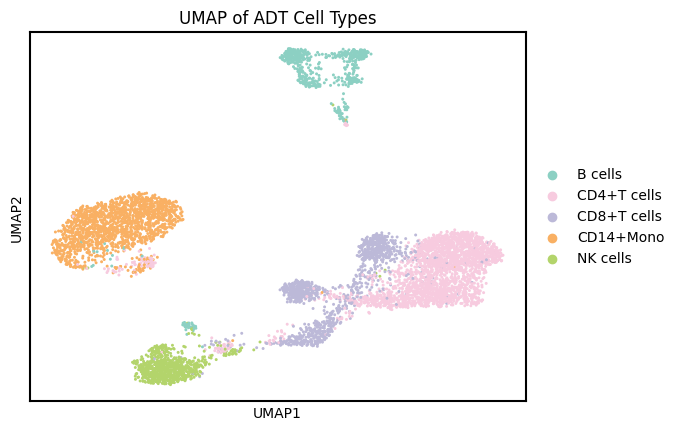

In [ ]:
sc.pp.normalize_total(pbmc, target_sum=1e4)
pbmc_raw = pbmc.copy()

sc.pp.log1p(pbmc)

sc.pp.highly_variable_genes(pbmc)

pbmc = pbmc[:, pbmc.var.highly_variable]
sc.pp.regress_out(pbmc, ["total_counts", "pct_counts_mt"])

sc.pp.neighbors(pbmc, n_neighbors=30, n_pcs=40)

sc.tl.umap(pbmc)

custom_colors = ["#8CD0C3", "#F7CBDF", "#BCB9D8", "#F9B063", "#B3D46B"]

fig = sc.pl.umap(
    pbmc,
    color="cell_type",
    palette=custom_colors,
    title="UMAP of ADT Cell Types",
    frameon=True,
    return_fig=True,
    show=False
)

ax = fig.axes[0]
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("black")
    spine.set_linewidth(1.5)

plt.show()
#sc.pl.umap(pbmc, color='cell_type', title='UMAP of ADT Cell Types')


# Calculating the SimRank similarity matrix

In [ ]:
# Step 1: Extract the adjacency matrix from the AnnData object (sparse matrix format)
adjacency_matrix_knn = pbmc.obsp['connectivities']  # Assuming the kNN graph is stored here (sparse matrix)

# Step 2: Convert the sparse matrix to a dense matrix and move it to PyTorch tensor
adj_matrix_dense = adjacency_matrix_knn.toarray()  # Convert to dense (NumPy array)

# Step 3: Convert the dense matrix to a PyTorch tensor and move to GPU
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
adj_matrix_tensor = torch.tensor(adj_matrix_dense, dtype=torch.float32).to(device)

# Step 4: Call the optimized SimRank function with the converted adjacency matrix
sim_matrix = simrank_similarity_optimized(adj_matrix_tensor, decay_factor=0.8, device=device)

# Step 5: Convert the result back to CPU if needed
sim_matrix_cpu = sim_matrix.cpu().numpy()

In [ ]:
# symmetrize the np array "sim_matrix_cpu"
symmetrized_raw_sim_matrix = sim_matrix_cpu + sim_matrix_cpu.transpose()

# Convert the transposed array to a Pandas DataFrame
sim_matrix_raw_df = pd.DataFrame(symmetrized_raw_sim_matrix)

# Now df_sim_matrix contains the transposed data in a DataFrame format

# Normalize the similarity matrix
sim_matrix_raw_df_norm = sim_matrix_raw_df.div(sim_matrix_raw_df.sum(axis=1), axis=0)
#print(sim_matrix_raw_df_norm.head())



In [ ]:
k=30
symmetrized_raw_sim_matrix_visualize = np.zeros_like(symmetrized_raw_sim_matrix)
for i in range(symmetrized_raw_sim_matrix.shape[0]):
  row = symmetrized_raw_sim_matrix[i, :]
  sorted_indices = np.argsort(row)[::-1]  # Sort in descending order
  top_k_indices = sorted_indices[:k]
  symmetrized_raw_sim_matrix_visualize[i, top_k_indices] = row[top_k_indices]


# Gaussian-kernel-transform and normalize the similarity matrix

In [ ]:

# Extract the sparse distance matrix from AnnData and SimRank similarity matrix
distances_knn = pbmc.obsp['distances']  # kNN distance matrix
sim_matrix_cpu = sim_matrix_cpu + sim_matrix_cpu.transpose()  # SimRank similarity matrix from the previous step

# Set k (number of most similar cells to consider)
k = 30

# Call the function to compute Gaussian kernel-based weights with SimRank intersection
weights_matrix = gaussian_kernel_weights_with_simrank(distances_knn, sim_matrix_cpu, k, device=device)

weights_matrix_cpu = weights_matrix.cpu().numpy()

In [ ]:
# Convert both matrices to PyTorch tensors
weights_tensor = torch.tensor(weights_matrix_cpu, dtype=torch.float32)
simrank_tensor = torch.tensor(sim_matrix_cpu, dtype=torch.float32)

# Move tensors to GPU if available
weights_tensor = weights_tensor.to(device)
simrank_tensor = simrank_tensor.to(device)

# Perform element-wise multiplication using PyTorch
final_weight_tensor = weights_tensor * simrank_tensor

sim_matrix_df = pd.DataFrame(final_weight_tensor.cpu().numpy())


# Normalize the similarity matrix
sim_matrix_df_norm = sim_matrix_df.div(sim_matrix_df.sum(axis=1), axis=0)
#print(sim_matrix_df_norm.head())


# Visualize the difference between KNN and simrank NN (before KNN filtering)

## CD4 proportion in CD8 neighbours

In [ ]:

# Get the indices of CD8 T cells and CD4 T cells
cd8_indices = np.where(pbmc.obs['cell_type'] == 'CD8+T cells')[0]
cd4_indices = np.where(pbmc.obs['cell_type'] != 'CD8+T cells')[0]
cd4_indices_set = set(cd4_indices)  # Convert to set for faster lookup

# Initialize a list to store the desired CD8 T cell indices
desired_cd8_indices = []

# Initialize lists to store CD4 T cell proportions
adj_cd4_proportions = []
weights_cd4_proportions = []
weights_cd4_proportions_filtered = []

# Iterate over each CD8 T cell
for i in cd8_indices:
    # Get neighbors from adj_matrix_dense
    adj_neighbors = np.nonzero(adj_matrix_dense[i, :])[0]
    # Get neighbors from symmetrized_raw_sim_matrix_visualize
    weights_neighbors = np.nonzero(symmetrized_raw_sim_matrix_visualize[i, :])[0]
    weights_neighbors_filtered = np.nonzero(weights_matrix_cpu[i, :])[0]


    # Compute CD4 T cell proportion in adj_neighbors
    adj_cd4_count = len(np.intersect1d(adj_neighbors, cd4_indices))
    adj_total_neighbors = len(adj_neighbors)
    adj_cd4_proportion = adj_cd4_count / adj_total_neighbors if adj_total_neighbors > 0 else 0
    adj_cd4_proportions.append(adj_cd4_proportion)

    # Compute CD4 T cell proportion in weights_neighbors
    weights_cd4_count = len(np.intersect1d(weights_neighbors, cd4_indices))
    weights_cd4_count_filtered = len(np.intersect1d(weights_neighbors_filtered, cd4_indices))
    weights_total_neighbors = len(weights_neighbors)
    weights_cd4_proportion = weights_cd4_count / weights_total_neighbors if weights_total_neighbors > 0 else 0
    weights_cd4_proportion_filtered = weights_cd4_count_filtered / weights_total_neighbors if weights_total_neighbors > 0 else 0
    weights_cd4_proportions.append(weights_cd4_proportion)
    weights_cd4_proportions_filtered.append(weights_cd4_proportion_filtered)

    # If adj_neighbors have a higher proportion of CD4 T cells than weights_neighbors
    if adj_cd4_proportion > weights_cd4_proportion:
        desired_cd8_indices.append(i)


/tmp/ipython-input-2833390146.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


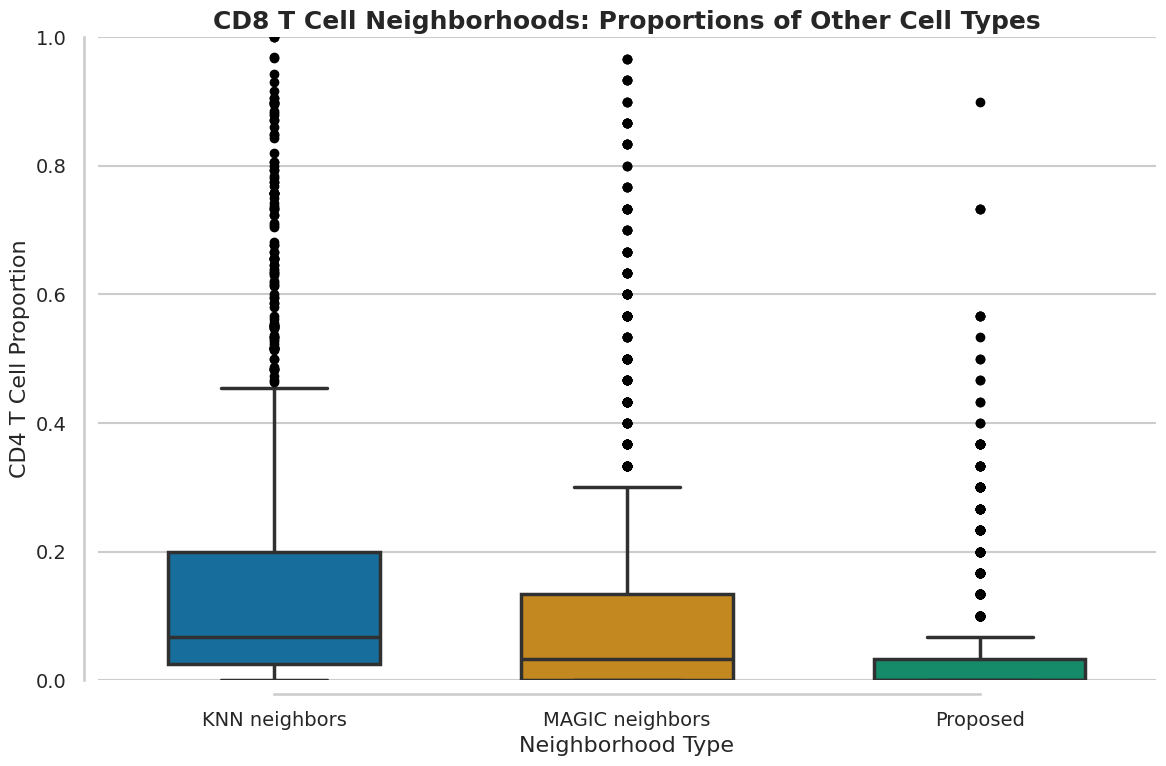

In [ ]:
adj_cd4_proportions = np.array(adj_cd4_proportions)
weights_cd4_proportions = np.array(weights_cd4_proportions)
weights_cd4_proportions_filtered = np.array(weights_cd4_proportions_filtered)

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'CD8_T_cell_index': cd8_indices,
    'KNN neighbors': adj_cd4_proportions,
    'Proposed': weights_cd4_proportions_filtered
})

# Melt the DataFrame for seaborn plotting
data_melted = data.melt(id_vars='CD8_T_cell_index', value_vars=['KNN neighbors', 'Proposed'], var_name='Neighborhood_Type', value_name='CD4_T_Cell_Proportion')
data_melted_magic = pd.read_csv('./magic_output/10x_10k/cd4_proportions_k_30.csv')
data_melted = pd.concat([data_melted, data_melted_magic], ignore_index=True)
# Save current style and context
original_style = sns.axes_style()
original_context = sns.plotting_context()

# Set the style and context for seaborn plots
sns.set_style('whitegrid')
sns.set_context('talk')


# Reset to original style and context
sns.set_style(original_style)
sns.set_context(original_context)

## CD8 proportion in CD4 neighbours

In [ ]:

# Get the indices of CD8 T cells and CD4 T cells
cd8_indices = np.where(pbmc.obs['cell_type'] != 'CD4+T cells')[0]
cd4_indices = np.where(pbmc.obs['cell_type'] == 'CD4+T cells')[0]
cd4_indices_set = set(cd4_indices)  # Convert to set for faster lookup

# Initialize a list to store the desired CD4 T cell indices
desired_cd4_indices = []

# Initialize lists to store CD4 T cell proportions
adj_cd8_proportions = []
weights_cd8_proportions = []
weights_cd8_proportions_filtered = []

# Iterate over each CD4 T cell
for i in cd4_indices:
    # Get neighbors from adj_matrix_dense
    adj_neighbors = np.nonzero(adj_matrix_dense[i, :])[0]
    # Get neighbors from symmetrized_raw_sim_matrix_visualize
    weights_neighbors = np.nonzero(symmetrized_raw_sim_matrix_visualize[i, :])[0]
    weights_neighbors_filtered = np.nonzero(weights_matrix_cpu[i, :])[0]

    # Compute CD8 T cell proportion in adj_neighbors
    adj_cd8_count = len(np.intersect1d(adj_neighbors, cd8_indices))
    adj_total_neighbors = len(adj_neighbors)
    adj_cd8_proportion = adj_cd8_count / adj_total_neighbors if adj_total_neighbors > 0 else 0
    adj_cd8_proportions.append(adj_cd8_proportion)

    # Compute CD8 T cell proportion in weights_neighbors
    weights_cd8_count = len(np.intersect1d(weights_neighbors, cd8_indices))
    weights_cd8_count_filtered = len(np.intersect1d(weights_neighbors_filtered, cd8_indices))
    weights_total_neighbors = len(weights_neighbors)
    weights_cd8_proportion = weights_cd8_count / weights_total_neighbors if weights_total_neighbors > 0 else 0
    weights_cd8_proportion_filtered = weights_cd8_count_filtered / weights_total_neighbors if weights_total_neighbors > 0 else 0
    weights_cd8_proportions.append(weights_cd8_proportion)
    weights_cd8_proportions_filtered.append(weights_cd8_proportion_filtered)

    # If adj_neighbors have a higher proportion of CD4 T cells than weights_neighbors
    if adj_cd8_proportion > weights_cd8_proportion:
        desired_cd4_indices.append(i)

/tmp/ipython-input-353273975.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


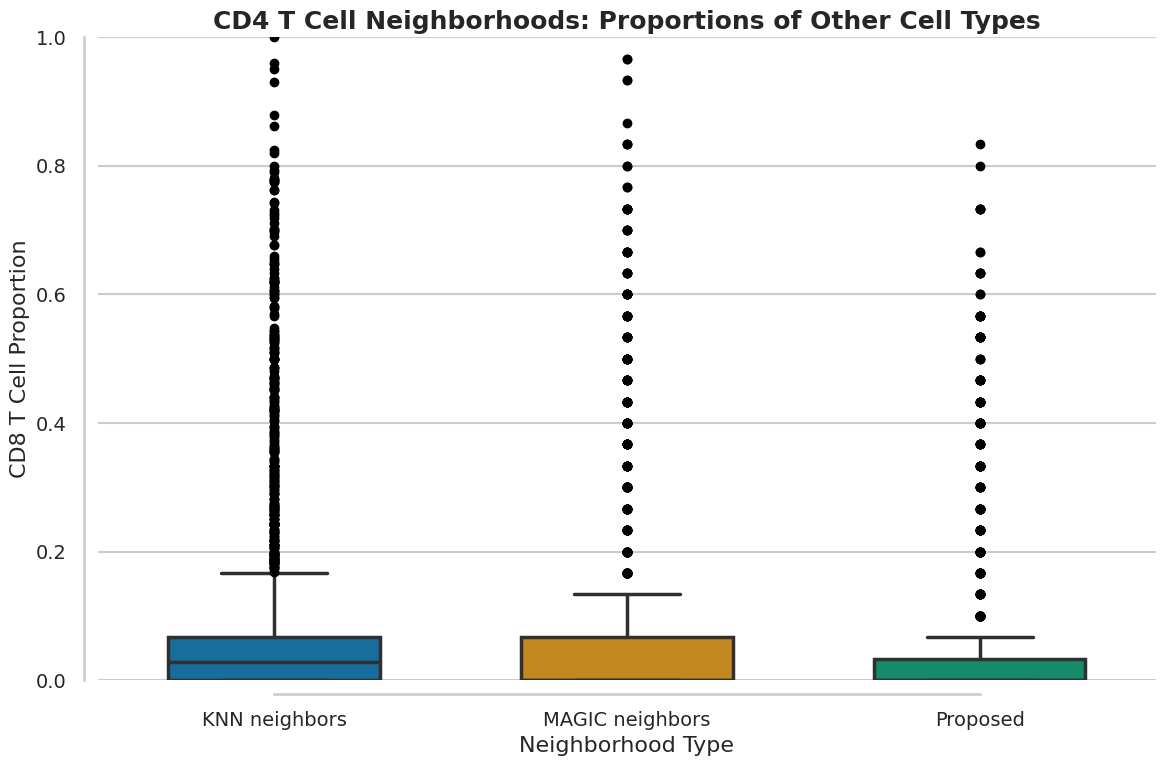

In [ ]:
# Convert the proportions lists to arrays for easier manipulation
adj_cd8_proportions = np.array(adj_cd8_proportions)
weights_cd8_proportions = np.array(weights_cd8_proportions)
weights_cd8_proportions_filtered = np.array(weights_cd8_proportions_filtered)

# Create a DataFrame for easier plotting
data = pd.DataFrame({
    'CD4_T_cell_index': cd4_indices,
    'KNN neighbors': adj_cd8_proportions,
    'Proposed': weights_cd8_proportions_filtered
})

# Melt the DataFrame for seaborn plotting
data_melted = data.melt(id_vars='CD4_T_cell_index', value_vars=['KNN neighbors', 'Proposed'], var_name='Neighborhood_Type', value_name='CD8_T_Cell_Proportion')
data_melted_magic = pd.read_csv('./magic_output/10x_10k/cd8_proportions_k_30.csv')
data_melted = pd.concat([data_melted, data_melted_magic], ignore_index=True)


# Save current style and context
original_style = sns.axes_style()
original_context = sns.plotting_context()

# Set the style and context for seaborn plots
sns.set_style('whitegrid')
sns.set_context('talk')

plt.figure(figsize=(12, 8))

# Create the boxplot with enhanced styling
ax = sns.boxplot(
    x='Neighborhood_Type',
    y='CD8_T_Cell_Proportion',
    data=data_melted,
    palette='colorblind',
    width=0.6,
    linewidth=2.5,
    fliersize=6,      # Size of the outlier markers
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'black',
        'markeredgecolor': 'black',
        'markersize': 6,
        'linestyle': 'none',
    },
    order=["KNN neighbors", "MAGIC neighbors", "Proposed"]
)

# Customize the plot
ax.set_title('CD4 T Cell Neighborhoods: Proportions of Other Cell Types', fontsize=18, fontweight='bold')
ax.set_xlabel('Neighborhood Type', fontsize=16)
ax.set_ylabel('CD8 T Cell Proportion', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

# Remove the top and right spines
sns.despine(offset=10, trim=True)
plt.ylim(bottom=0, top=1)
plt.tight_layout()
plt.show()

# Reset to original style and context
sns.set_style(original_style)
sns.set_context(original_context)

# Varying K

In [ ]:
# Define the range of k values
k_values = list(range(5, 51, 5))

# These lists will hold the *entire* distribution (not just mean) for each k
# for CD4+ T cell proportions in neighborhoods of CD8+ T cells:
all_cd4_in_cd8_data = []  # will be turned into a DataFrame later

# Similarly, for CD8+ T cell proportions in neighborhoods of CD4+ T cells:
all_cd8_in_cd4_data = []

# Initialize lists to store the results
knn_cd4 = []
simrank_cd4 = []
simrank_filtered_cd4 = []
knn_cd8 = []
simrank_cd8 = []
simrank_filtered_cd8 = []

for k in k_values:

  datafile = "./10x_10k/pbmc_10x_10k.h5"
  pbmc = sc.read_10x_h5(datafile, gex_only=True)
  pbmc.var_names_make_unique()
  sc.pp.filter_genes(pbmc, min_counts=1)

  pbmc.obs['cell_type'] = ADT_df['x'].values
  pbmc = pbmc[pbmc.obs['cell_type'] != 'Uncertain']



  # annotate the group of mitochondrial genes as "mt"
  pbmc.var["mt"] = pbmc.var_names.str.startswith("MT-")
  sc.pp.calculate_qc_metrics(
      pbmc, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True
  )

  sc.pp.normalize_total(pbmc, target_sum=1e4)
  pbmc_raw = pbmc.copy()

  sc.pp.log1p(pbmc)

  sc.pp.highly_variable_genes(pbmc)

  pbmc = pbmc[:, pbmc.var.highly_variable]
  sc.pp.regress_out(pbmc, ["total_counts", "pct_counts_mt"])

  sc.pp.neighbors(pbmc, n_neighbors=k, n_pcs=40)

  sc.tl.umap(pbmc)


  #sc.pl.umap(pbmc, color='cell_type', title='UMAP of ADT Cell Types')

  # Step 1: Extract the adjacency matrix from the AnnData object (sparse matrix format)
  adjacency_matrix_knn = pbmc.obsp['connectivities']  # Assuming the kNN graph is stored here (sparse matrix)

  # Step 2: Convert the sparse matrix to a dense matrix and move it to PyTorch tensor
  adj_matrix_dense = adjacency_matrix_knn.toarray()  # Convert to dense (NumPy array)

  # Step 3: Convert the dense matrix to a PyTorch tensor and move to GPU if necessary
  #device = 'cuda' if torch.cuda.is_available() else 'cpu'
  adj_matrix_tensor = torch.tensor(adj_matrix_dense, dtype=torch.float32).to(device)

  # Step 4: Call the optimized SimRank function with the converted adjacency matrix
  sim_matrix = simrank_similarity_optimized(adj_matrix_tensor, decay_factor=0.8, device=device)

  # Step 5: Convert the result back to CPU if needed
  sim_matrix_cpu = sim_matrix.cpu().numpy()

  # symmetrize the np array "sim_matrix_cpu"
  symmetrized_raw_sim_matrix = sim_matrix_cpu + sim_matrix_cpu.transpose()

  # Convert the transposed array to a Pandas DataFrame
  sim_matrix_raw_df = pd.DataFrame(symmetrized_raw_sim_matrix)

  # Now df_sim_matrix contains the transposed data in a DataFrame format

  # Normalize the similarity matrix
  sim_matrix_raw_df_norm = sim_matrix_raw_df.div(sim_matrix_raw_df.sum(axis=1), axis=0)
  #print(sim_matrix_raw_df_norm.head())

  # prompt: only keep the largest K values in each row of symmetrized_raw_sim_matrix
  symmetrized_raw_sim_matrix_visualize = np.zeros_like(symmetrized_raw_sim_matrix)
  for i in range(symmetrized_raw_sim_matrix.shape[0]):
    row = symmetrized_raw_sim_matrix[i, :]
    sorted_indices = np.argsort(row)[::-1]  # Sort in descending order
    top_k_indices = sorted_indices[:k]
    symmetrized_raw_sim_matrix_visualize[i, top_k_indices] = row[top_k_indices]

    # Extract the sparse distance matrix from AnnData and SimRank similarity matrix
  distances_knn = pbmc.obsp['distances']  # kNN distance matrix
  sim_matrix_cpu = sim_matrix_cpu + sim_matrix_cpu.transpose()  # SimRank similarity matrix from the previous step


  # Call the function to compute Gaussian kernel-based weights with SimRank intersection
  weights_matrix = gaussian_kernel_weights_with_simrank(distances_knn, sim_matrix_cpu, k, device=device)

  # Optionally, move the weights back to CPU and convert to NumPy for further processing
  weights_matrix_cpu = weights_matrix.cpu().numpy()

  # Convert both matrices to PyTorch tensors
  weights_tensor = torch.tensor(weights_matrix_cpu, dtype=torch.float32)
  simrank_tensor = torch.tensor(sim_matrix_cpu, dtype=torch.float32)

  # Move tensors to GPU if available
  weights_tensor = weights_tensor.to(device)
  simrank_tensor = simrank_tensor.to(device)

  # Perform element-wise multiplication using PyTorch
  final_weight_tensor = weights_tensor * simrank_tensor

  # Optionally, move the result back to CPU and convert to NumPy for further use
  sim_matrix_df = pd.DataFrame(final_weight_tensor.cpu().numpy())


  # Normalize the similarity matrix
  sim_matrix_df_norm = sim_matrix_df.div(sim_matrix_df.sum(axis=1), axis=0)
  #print(sim_matrix_df_norm.head())


  # Get the indices of CD8 T cells and CD4 T cells
  cd8_indices = np.where(pbmc.obs['cell_type'] == 'CD8+T cells')[0]
  cd4_indices = np.where(pbmc.obs['cell_type'] != 'CD8+T cells')[0]
  cd4_indices_set = set(cd4_indices)  # Convert to set for faster lookup

  # Initialize a list to store the desired CD8 T cell indices
  desired_cd8_indices = []

  # Initialize lists to store CD4 T cell proportions
  adj_cd4_proportions = []
  weights_cd4_proportions = []
  weights_cd4_proportions_filtered = []

  # Iterate over each CD8 T cell
  for i in cd8_indices:
      # Get neighbors from adj_matrix_dense
      adj_neighbors = np.nonzero(adj_matrix_dense[i, :])[0]
      # Get neighbors from symmetrized_raw_sim_matrix_visualize
      weights_neighbors = np.nonzero(symmetrized_raw_sim_matrix_visualize[i, :])[0]
      weights_neighbors_filtered = np.nonzero(weights_matrix_cpu[i, :])[0]

      # Compute CD4 T cell proportion in adj_neighbors
      adj_cd4_count = len(np.intersect1d(adj_neighbors, cd4_indices))
      adj_total_neighbors = len(adj_neighbors)
      adj_cd4_proportion = adj_cd4_count / adj_total_neighbors if adj_total_neighbors > 0 else 0
      adj_cd4_proportions.append(adj_cd4_proportion)

      # Compute CD4 T cell proportion in weights_neighbors
      weights_cd4_count = len(np.intersect1d(weights_neighbors, cd4_indices))
      weights_cd4_count_filtered = len(np.intersect1d(weights_neighbors_filtered, cd4_indices))
      weights_total_neighbors = len(weights_neighbors)
      weights_cd4_proportion = weights_cd4_count / weights_total_neighbors if weights_total_neighbors > 0 else 0
      weights_cd4_proportion_filtered = weights_cd4_count_filtered / weights_total_neighbors if weights_total_neighbors > 0 else 0
      weights_cd4_proportions.append(weights_cd4_proportion)
      weights_cd4_proportions_filtered.append(weights_cd4_proportion_filtered)

      # If adj_neighbors have a higher proportion of CD4 T cells than weights_neighbors
      if adj_cd4_proportion > weights_cd4_proportion:
          desired_cd8_indices.append(i)

  # Store *all* the data points (instead of just mean)
  # This will let us make a box plot later.
  for val in adj_cd4_proportions:
      all_cd4_in_cd8_data.append({'k': k, 'method': 'KNN', 'proportion': val})
  #for val in weights_cd4_proportions:
      #all_cd4_in_cd8_data.append({'k': k, 'method': 'SimRank', 'proportion': val})
  for val in weights_cd4_proportions_filtered:
      all_cd4_in_cd8_data.append({'k': k, 'method': 'Proposed', 'proportion': val})
  df_cd4_in_cd8 = pd.DataFrame(all_cd4_in_cd8_data)  # Data for: CD4 T cell proportion in neighborhoods of CD8 T

  # Convert the proportions lists to arrays for easier manipulation
  adj_cd4_proportions = np.array(adj_cd4_proportions)
  weights_cd4_proportions = np.array(weights_cd4_proportions)
  weights_cd4_proportions_filtered = np.array(weights_cd4_proportions_filtered)



  # Get the indices of CD8 T cells and CD4 T cells
  cd8_indices = np.where(pbmc.obs['cell_type'] != 'CD4+T cells')[0]
  cd4_indices = np.where(pbmc.obs['cell_type'] == 'CD4+T cells')[0]
  cd4_indices_set = set(cd4_indices)  # Convert to set for faster lookup

  # Initialize a list to store the desired CD4 T cell indices
  desired_cd4_indices = []

  # Initialize lists to store CD4 T cell proportions
  adj_cd8_proportions = []
  weights_cd8_proportions = []
  weights_cd8_proportions_filtered = []

  # Iterate over each CD4 T cell
  for i in cd4_indices:
      # Get neighbors from adj_matrix_dense
      adj_neighbors = np.nonzero(adj_matrix_dense[i, :])[0]
      # Get neighbors from symmetrized_raw_sim_matrix_visualize
      weights_neighbors = np.nonzero(symmetrized_raw_sim_matrix_visualize[i, :])[0]
      weights_neighbors_filtered = np.nonzero(weights_matrix_cpu[i, :])[0]

      # Compute CD8 T cell proportion in adj_neighbors
      adj_cd8_count = len(np.intersect1d(adj_neighbors, cd8_indices))
      adj_total_neighbors = len(adj_neighbors)
      adj_cd8_proportion = adj_cd8_count / adj_total_neighbors if adj_total_neighbors > 0 else 0
      adj_cd8_proportions.append(adj_cd8_proportion)

      # Compute CD8 T cell proportion in weights_neighbors
      weights_cd8_count = len(np.intersect1d(weights_neighbors, cd8_indices))
      weights_cd8_count_filtered = len(np.intersect1d(weights_neighbors_filtered, cd8_indices))
      weights_total_neighbors = len(weights_neighbors)
      weights_cd8_proportion = weights_cd8_count / weights_total_neighbors if weights_total_neighbors > 0 else 0
      weights_cd8_proportion_filtered = weights_cd8_count_filtered / weights_total_neighbors if weights_total_neighbors > 0 else 0
      weights_cd8_proportions.append(weights_cd8_proportion)
      weights_cd8_proportions_filtered.append(weights_cd8_proportion_filtered)

      # If adj_neighbors have a higher proportion of CD4 T cells than weights_neighbors
      if adj_cd8_proportion > weights_cd8_proportion:
          desired_cd4_indices.append(i)

  for val in adj_cd8_proportions:
      all_cd8_in_cd4_data.append({'k': k, 'method': 'KNN', 'proportion': val})
  #for val in weights_cd8_proportions:
      #all_cd8_in_cd4_data.append({'k': k, 'method': 'SimRank', 'proportion': val})
  for val in weights_cd8_proportions_filtered:
      all_cd8_in_cd4_data.append({'k': k, 'method': 'Proposed', 'proportion': val})
  df_cd8_in_cd4 = pd.DataFrame(all_cd8_in_cd4_data)  # Data for: CD8 T cell proportion in neighborhoods of CD4 T

  # Convert the proportions lists to arrays for easier manipulation
  adj_cd8_proportions = np.array(adj_cd8_proportions)
  weights_cd8_proportions = np.array(weights_cd8_proportions)
  weights_cd8_proportions_filtered = np.array(weights_cd8_proportions_filtered)



  # Calculate mean proportions for current k
  knn_cd4.append(np.mean(adj_cd4_proportions))
  simrank_cd4.append(np.mean(weights_cd4_proportions))
  simrank_filtered_cd4.append(np.mean(weights_cd4_proportions_filtered))
  knn_cd8.append(np.mean(adj_cd8_proportions))
  simrank_cd8.append(np.mean(weights_cd8_proportions))
  simrank_filtered_cd8.append(np.mean(weights_cd8_proportions_filtered))

/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipython-input-4184813650.py:32: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  pbmc.var["mt"] = pbmc.var_names.str.startswith("MT-")
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/dist-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/usr/local/lib/python3.12/

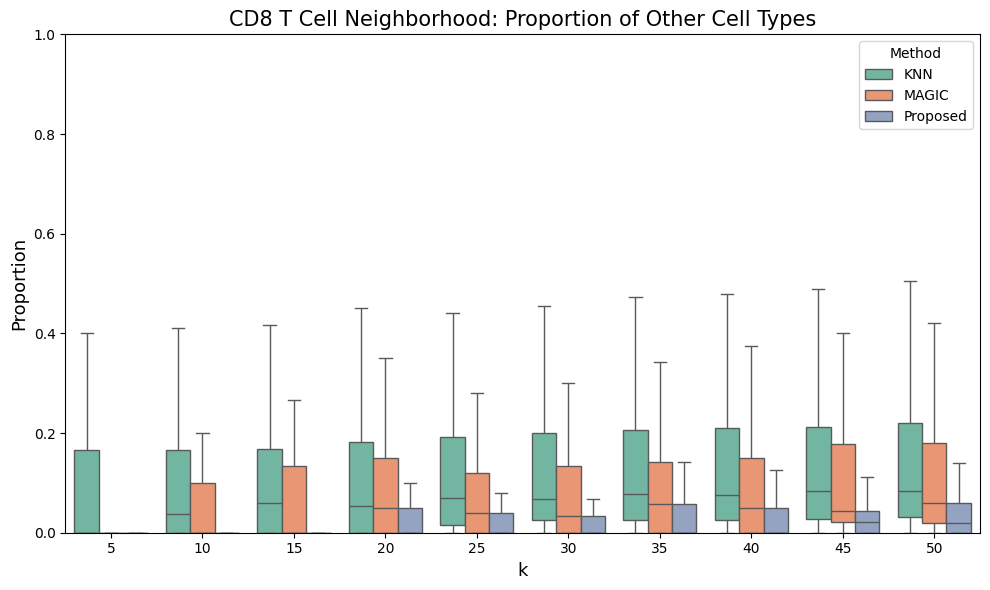

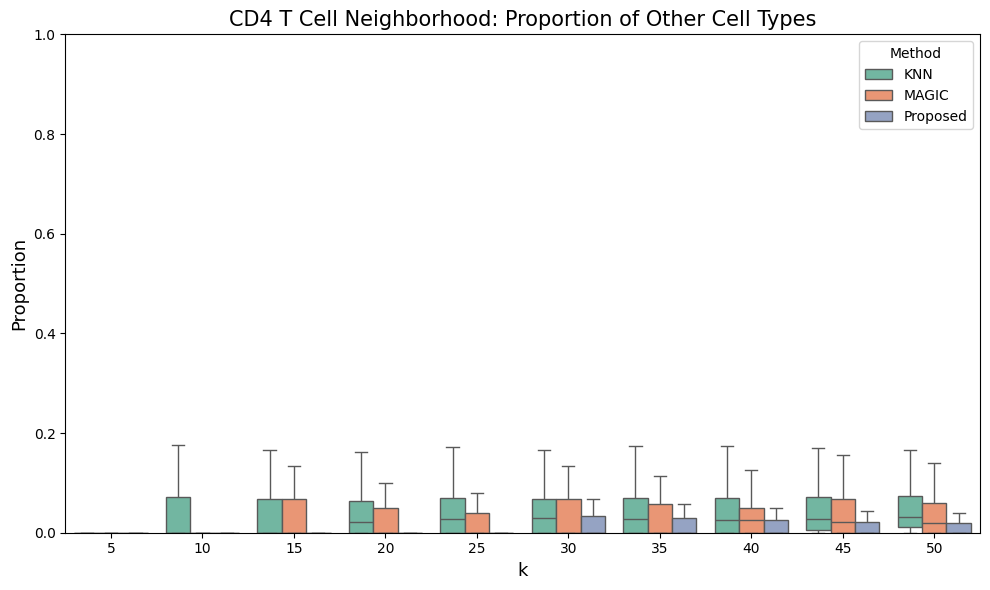

In [ ]:
# A) Box plot for CD4 T cell proportion in neighborhoods of CD8 T cells

df_cd4_in_cd8_magic = pd.read_csv('./magic_output/10x_10k/cd4_proportions_vary_k.csv')
df_cd4_in_cd8 = pd.concat([df_cd4_in_cd8, df_cd4_in_cd8_magic], ignore_index=True)


plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cd4_in_cd8,
    x='k',            # group by the different k values
    y='proportion',
    hue='method',     # show KNN, SimRank, SimRank Filtered side by side
    palette='Set2',
    hue_order=["KNN", "MAGIC", "Proposed"],
    showfliers=False
)
plt.ylim(bottom=0, top = 1)
plt.title('CD8 T Cell Neighborhood: Proportion of Other Cell Types', fontsize=15)
plt.xlabel('k', fontsize=13)
plt.ylabel('Proportion', fontsize=13)
plt.legend(title='Method')
plt.tight_layout()
plt.show()

# B) Box plot for CD8 T cell proportion in neighborhoods of CD4 T cells

df_cd8_in_cd4_magic = pd.read_csv('./magic_output/10x_10k/cd8_proportions_vary_k.csv')
df_cd8_in_cd4 = pd.concat([df_cd8_in_cd4, df_cd8_in_cd4_magic], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_cd8_in_cd4,
    x='k',
    y='proportion',
    hue='method',
    palette='Set2',
    hue_order=["KNN", "MAGIC", "Proposed"],
    showfliers=False
)
plt.ylim(bottom=0, top = 1)
plt.title('CD4 T Cell Neighborhood: Proportion of Other Cell Types', fontsize=15)
plt.xlabel('k', fontsize=13)
plt.ylabel('Proportion', fontsize=13)
plt.legend(title='Method')
plt.tight_layout()
plt.show()

/tmp/ipython-input-2126211337.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cd4_in_cd8_filt['method'] = df_cd4_in_cd8_filt['method'].replace('Proposed', 'SCORED')


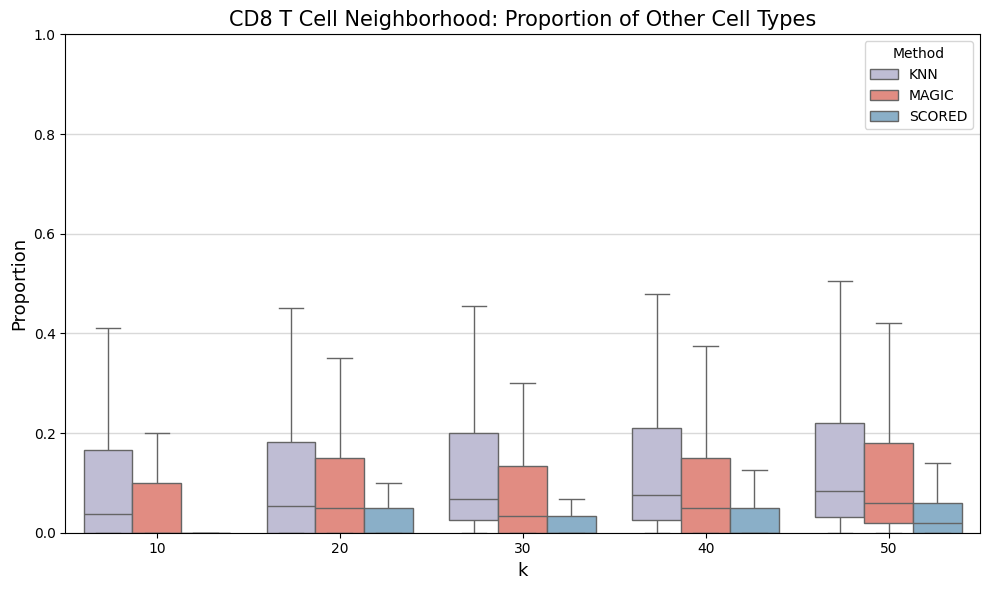

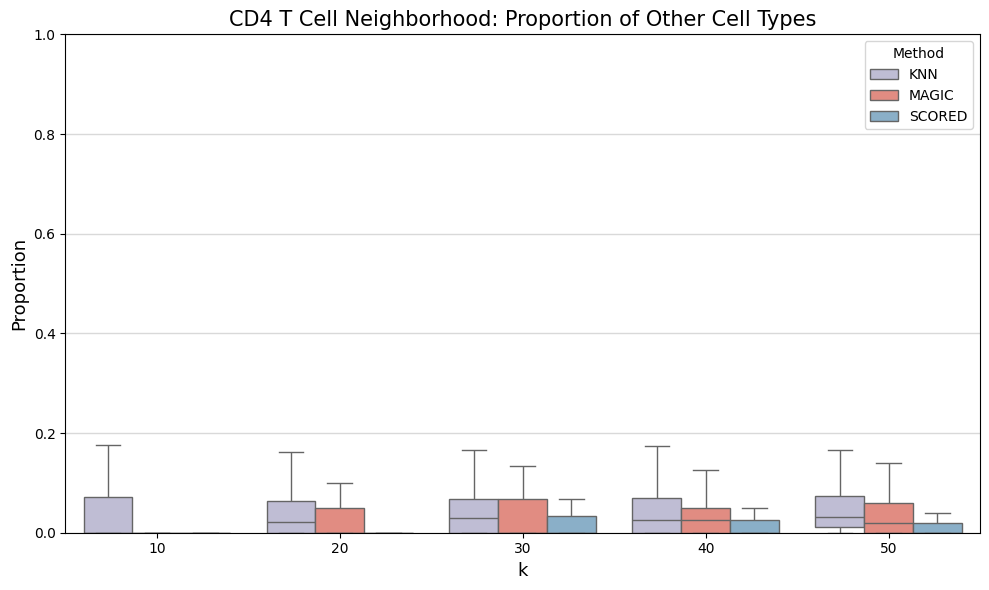

In [ ]:
# beautify

# 1) pick the ks you actually want to show
selected_ks = [10, 20, 30, 40, 50]

# 2) filter your data
df_cd4_in_cd8_filt = df_cd4_in_cd8[df_cd4_in_cd8['k'].isin(selected_ks)]

# prompt: In the "method" column of df_cd4_in_cd8_filt, I want to change "Proposed" to "SCORED"

df_cd4_in_cd8_filt['method'] = df_cd4_in_cd8_filt['method'].replace('Proposed', 'SCORED')

df_cd8_in_cd4_filt = df_cd8_in_cd4[df_cd8_in_cd4['k'].isin(selected_ks)]
# prompt: In the "method" column of df_cd8_in_cd4_filt, I want to change "Proposed" to "SCORED"

df_cd8_in_cd4_filt['method'] = df_cd8_in_cd4_filt['method'].replace('Proposed', 'SCORED')


# 3) define your hue‐order and colour mapping
hue_order = ["KNN", "MAGIC", "SCORED"]
palette = {
    "KNN":      "#BCB9D8",
    "MAGIC":    "#F18072",
    "SCORED": "#80B1D2"
}

def plot_box(df, title):
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x='k', y='proportion', hue='method',
        order=selected_ks, hue_order=hue_order,
        palette=palette, showfliers=False, ax=ax
    )
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel('k', fontsize=13)
    ax.set_ylabel('Proportion', fontsize=13)
    ax.legend(title='Method', loc='upper right')

    # horizontal grey grid lines
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color='0.85', linewidth=1)
    ax.xaxis.grid(False)

    plt.tight_layout()
    plt.show()

# --- plots ---
plot_box(df_cd4_in_cd8_filt, 'CD8 T Cell Neighborhood: Proportion of Other Cell Types')
plot_box(df_cd8_in_cd4_filt, 'CD4 T Cell Neighborhood: Proportion of Other Cell Types')

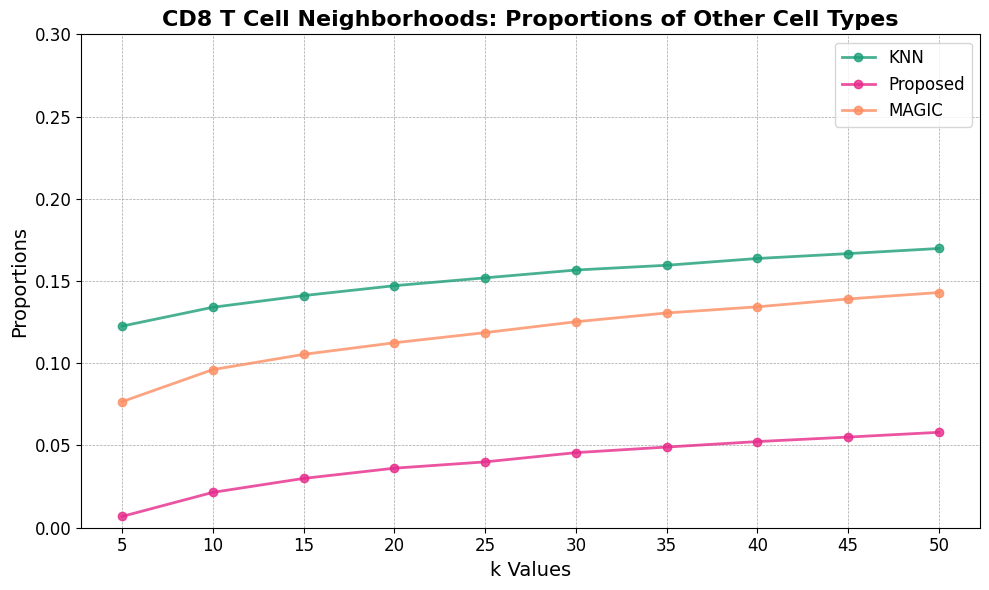

In [ ]:
magic_cd4 = np.load('./magic_output/10x_10k/magic_cd4.npy')
# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_cd4, marker='o', linestyle='-', linewidth=2, color='#1b9e77', label='KNN', alpha=0.8)
plt.plot(k_values, simrank_filtered_cd4, marker='o', linestyle='-', linewidth=2, color='#e7298a', label='Proposed', alpha=0.8)
plt.plot(k_values, magic_cd4, marker='o', linestyle='-', linewidth=2, color='#fc8d62', label='MAGIC', alpha=0.8)


# Beautify the plot
plt.title("CD8 T Cell Neighborhoods: Proportions of Other Cell Types", fontsize=16, weight='bold')
plt.xlabel("k Values", fontsize=14)
plt.ylabel("Proportions", fontsize=14)
plt.xticks(k_values, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.ylim(bottom=0, top=0.3)

# Show the plot
plt.show()

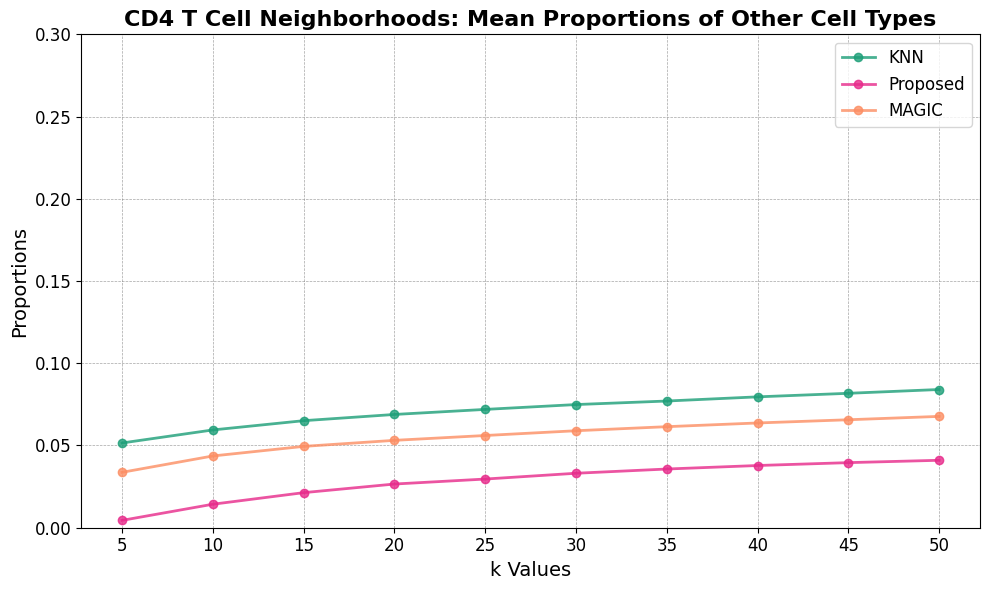

In [ ]:
magic_cd8 = np.load('./magic_output/10x_10k/magic_cd8.npy')

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_cd8, marker='o', linestyle='-', linewidth=2, color='#1b9e77', label='KNN', alpha=0.8)
plt.plot(k_values, simrank_filtered_cd8, marker='o', linestyle='-', linewidth=2, color='#e7298a', label='Proposed', alpha=0.8)
plt.plot(k_values, magic_cd8, marker='o', linestyle='-', linewidth=2, color='#fc8d62', label='MAGIC', alpha=0.8)


# Beautify the plot
plt.title("CD4 T Cell Neighborhoods: Mean Proportions of Other Cell Types", fontsize=16, weight='bold')
plt.xlabel("k Values", fontsize=14)
plt.ylabel("Proportions", fontsize=14)
plt.xticks(k_values, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.ylim(bottom=0, top = 0.3)
# Show the plot
plt.show()